# Extension of Diversity Vector to Narrative Diversity (D_narr)

-> Sentiment trajectory divergence across stories

**Approach:**
- For each story extract a normalized sentiment arc
- Per-sentence sentiment from the transformer classifier `siebert/sentiment-roberta-large-english` (VADER as an appendix for comparison against a lexicon-based approach)
- Binned into 10 equal-proportion narrative segments and averaged per segment
- Narrative diversity per prompt-source group via mean pairwise Euclidean distance between arcs

**Reference:** Reagan et al. (2016) found that the emotional arcs of stories are dominated by six basic shapes (theoretical framing but we do not reproduce their lexicon-based sentiment scoring)

**Metric formula:**
$$D_{\text{narr}} = \frac{1}{\binom{n}{2}} \sum_{i < j} \| \mathbf{a}_i - \mathbf{a}_j \|_2$$
where $\mathbf{a}_i$ is the binned sentiment arc of story $i$.

**Data:**
Generated data from `data_generation/generations/` switchable via `DOMAIN`:
- **`storytelling_n200`**: WritingPrompts (Fan et al., 2018) test split, 200 prompts x 4 LLMs x 5 samples + >=5 human reference stories/prompt
- **`translation_ref3`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=3 human translations/paragraph
- **`translation_ref4`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=4 human translations/paragraph

In [32]:
# Load libraries
import json
import time
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from scipy.stats import entropy as scipy_entropy  # kruskal, mannwhitneyu, chi2_contingency removed (significance testing dropped)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import nltk
from nltk.tokenize import sent_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings('ignore')
np.random.seed(42)

In [33]:
# NLTK sentence tokenizer
import ssl

# Fix SSL certificate verification for NLTK downloads (e.g., on macOS)
try:
    import certifi
    ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
except ModuleNotFoundError:
    ssl._create_default_https_context = ssl._create_unverified_context

nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)

# Fail here if the download still didn't work
nltk.data.find('tokenizers/punkt_tab/english/')

# Print-oriented plotting defaults
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 10,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10})


In [34]:
# Configuration
DOMAIN = 'translation_ref3'  # 'storytelling_n200', 'translation_ref3' or 'translation_ref4'

ARC_LENGTH = 10          # number of points to bin each sentiment arc into
MIN_SENTENCES = 10       # minimum sentences required to include a story (must be >= ARC_LENGTH)

# Minimum valid stories required for a (prompt, source) group to be included: 
# same >=2 pairwise minimum used throughout
MIN_STORIES_PER_GROUP = 2

# Grids for the "Sensitivity & Robustness Checks" section 
MIN_SENTENCES_GRID = [8, 10, 15]

SENTIMENT_METHOD = 'transformer'  # 'transformer' (siebert/sentiment-roberta-large-english) or 'vader'

SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
N_PROMPTS = 200


FIG_DIR = Path(f'../../figures/narrative_diversity/{DOMAIN}')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path(f'../../metrics/03_narrative_diversity/tables/{DOMAIN}')
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Domain:                       {DOMAIN}")
print(f"  Arc length (bins):            {ARC_LENGTH}")
print(f"  Minimum sentences per story:  {MIN_SENTENCES}")
print(f"  Minimum stories per group:    {MIN_STORIES_PER_GROUP}")
print(f"  MIN_SENTENCES grid:           {MIN_SENTENCES_GRID}")
print(f"  Sentiment method:             {SENTIMENT_METHOD}")

Configuration:
  Domain:                       translation_ref3
  Arc length (bins):            10
  Minimum sentences per story:  10
  Minimum stories per group:    2
  MIN_SENTENCES grid:           [8, 10, 15]
  Sentiment method:             transformer


## Load Dataset

In [35]:
# Repo root importable regardless of the kernel's working directory
import sys

def find_repo_root(start=None):
    start = Path(start or Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations').is_dir():
            return p
    raise FileNotFoundError("Could not locate the repo root (expected 'metrics/metrics_lib/' and "
                             "'data_generation/generations/')")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


# Import common functions and constants
from common import data_prep
from common import MODEL_LABELS, MODEL_COLORS, MODEL_ORDER

DATA_DIR = data_prep.GENERATIONS_DIR / DOMAIN
print(f"DOMAIN = {DOMAIN!r}  ({DATA_DIR})")

_df = data_prep.load_texts(DOMAIN, n_prompts=N_PROMPTS)
df = _df[['prompt_id', 'source', 'story_id', 'text']].reset_index(drop=True)
df['model'] = df['source'].map(MODEL_LABELS)

n_dropped = {s: 5 * N_PROMPTS - int((df.source == s).sum()) for s in SOURCES if s != 'human'}
print(f"Loaded: {len(df)} texts ({df['prompt_id'].nunique()} prompts x {len(SOURCES)} sources)")
print(f"Dropped (quality filter): {n_dropped}")
df.head()

DOMAIN = 'translation_ref3'  (/Users/thwin/Desktop/Uni/Master/Masterarbeit/Masterthesis/data_generation/generations/translation_ref3)
Loaded: 4403 texts (200 prompts x 5 sources)
Dropped (quality filter): {'llama': 9, 'mistral': 27, 'qwen': 166, 'gemma': 64}


,prompt_id,source,story_id,text,model
0,0,human,0,Though – what am I saying? – everyone does it;...,Human
1,0,human,1,"Why do I say that, though? Everybody does it –...",Human
2,0,human,2,"But, gentlemen, whoever can pride himself on h...",Human
3,1,human,0,K. waited from day to day throughout the follo...,Human
4,1,human,1,DURING the next week K. waited day after day f...,Human


## Compute Sentiment Arcs

In [36]:
# Per-sentence sentiment: scored once over every sentence in the corpus and cached to disk (domain- and method-specific)

# The cache stores {'fingerprint': ..., 'df_sent': ...}
# The fingerprint is a hash of exactly what determines the scores:
# identity + text of every scored row, plus SENTIMENT_METHOD

# DEVICE forced to CPU for the transformer method

import hashlib

SENT_CACHE = TABLE_DIR / f'sentence_sentiment_{SENTIMENT_METHOD}.pkl'


def tokenize_sentences(text):
    # Sentence-tokenize and keep every non-empty sentence (no length / word-count filter)
    return [s.strip() for s in sent_tokenize(text) if s.strip()]


def corpus_fingerprint(df, method):
    # Order-independent hash over the identity + text of every row that gets scored.
    keys = (df['prompt_id'].astype(str) + '|' + df['source'].astype(str) + '|'
            + df['story_id'].astype(str) + '|' + df['text'].fillna(''))

    # Hash the method name first, then every row's key in sorted order (so the hash is independent of row order)
    h = hashlib.sha256(method.encode())
    for k in sorted(keys):
        h.update(k.encode('utf-8'))
    return h.hexdigest()


# Load or compute per-sentence sentiment scores
FINGERPRINT = corpus_fingerprint(df, SENTIMENT_METHOD)
cached = pd.read_pickle(SENT_CACHE) if SENT_CACHE.exists() else None

# Use the cache only if it was built from the same corpus + method
if isinstance(cached, dict) and cached.get('fingerprint') == FINGERPRINT:
    df_sent = cached['df_sent']
    print(f"Loaded cached per-sentence sentiment: {SENT_CACHE}  ({len(df_sent)} texts)")

# Otherwise score every sentence in the corpus once and cache it to disk
else:
    if cached is not None:
        print("Cache present but stale (corpus or method changed) - re-scoring ...")

    if SENTIMENT_METHOD == 'transformer':
        from transformers import pipeline

        DEVICE = -1       # forced CPU
        BATCH_SIZE = 32   # batch size for the transformer scoring pipeline

        sentiment_pipe = pipeline('sentiment-analysis', model='siebert/sentiment-roberta-large-english',
                                   device=DEVICE, truncation=True)
        print(f"Loaded siebert/sentiment-roberta-large-english on device={DEVICE}")

        def score_sentences_batch(sentences, batch_size=BATCH_SIZE):
            # Continuous signed score in [-1, 1]: 2*P(positive) - 1, so a 50/50-uncertain sentence ~0
            results = sentiment_pipe(sentences, batch_size=batch_size)
            p_positive = np.array([r['score'] if r['label'] == 'POSITIVE' else 1 - r['score'] for r in results])
            return 2 * p_positive - 1

    elif SENTIMENT_METHOD == 'vader':
        vader_analyzer = SentimentIntensityAnalyzer()

        def score_sentences_batch(sentences, batch_size=None):
            return np.array([vader_analyzer.polarity_scores(s)['compound'] for s in sentences])

    else:
        raise ValueError(f"Unknown SENTIMENT_METHOD {SENTIMENT_METHOD!r}")

    # Tokenize every text (short texts kept: the MIN_SENTENCES filter is applied later, off the cache)
    df['sentences'] = df['text'].apply(tokenize_sentences)
    df_tok = df[df['sentences'].map(len) > 0].copy()

    # Flatten to one list of sentences, tracking which row each came from
    flat_sentences, row_ids = [], []
    for idx, sents in zip(df_tok.index, df_tok['sentences']):
        flat_sentences.extend(sents)
        row_ids.extend([idx] * len(sents))

    print(f"Scoring {len(flat_sentences):,} sentences ...")
    t0 = time.time()
    flat_scores = score_sentences_batch(flat_sentences)
    print(f"Done in {time.time() - t0:.0f}s")

    # Reassemble the per-sentence scores per text
    scores_by_row = {}
    for rid, score in zip(row_ids, flat_scores):
        scores_by_row.setdefault(rid, []).append(score)

    df_tok['sent_scores'] = df_tok.index.map(lambda i: np.asarray(scores_by_row[i], dtype=float))
    df_tok['n_sentences'] = df_tok['sent_scores'].map(len)
    df_sent = df_tok.drop(columns=['sentences']).reset_index(drop=True)

    pd.to_pickle({'fingerprint': FINGERPRINT, 'df_sent': df_sent}, SENT_CACHE)
    print(f"Saved per-sentence sentiment to cache: {SENT_CACHE}")

# Consistency check: every cached row must still exist in the current corpus
matched = df.merge(df_sent[['prompt_id', 'source', 'story_id']],
                   on=['prompt_id', 'source', 'story_id'], how='inner').shape[0]
assert matched == len(df_sent), (
    f"cache/corpus mismatch: {len(df_sent) - matched} cached rows not in the current corpus")

print(f"Texts with >= 1 sentence: {len(df_sent)}  "
      f"(corpus rows not scored: {len(df) - matched}; "
      f"sentence count: min={df_sent['n_sentences'].min()}, "
      f"median={df_sent['n_sentences'].median():.0f}, max={df_sent['n_sentences'].max()})")


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 49051.08it/s]


Loaded siebert/sentiment-roberta-large-english on device=-1
Scoring 88,045 sentences ...
Done in 6581s
Saved per-sentence sentiment to cache: ../../metrics/03_narrative_diversity/tables/translation_ref3/sentence_sentiment_transformer.pkl
Texts with >= 1 sentence: 4403  (corpus rows not scored: 0; sentence count: min=3, median=16, max=242)


### Bin Sentences into Sentiment Arcs

Re-bin the cached per-sentence scores into fixed-length arcs

In [63]:
def bin_to_arc(scores, arc_length=ARC_LENGTH):
    # Split per-sentence sentiment scores into `arc_length` contiguous, roughly equal-sized
    # narrative segments and average each segment.

    scores = np.asarray(scores, dtype=float)

    # If there are fewer sentences than the desired arc length, interpolate to the desired length
    if len(scores) < arc_length:
        x_old = np.linspace(0, 1, len(scores))
        x_new = np.linspace(0, 1, arc_length)
        return np.interp(x_new, x_old, scores)

    # Otherwise, split into contiguous bins and average each bin
    bins = np.array_split(scores, arc_length)
    return np.array([b.mean() for b in bins])


def build_arcs(df_sent, min_sentences=MIN_SENTENCES, arc_length=ARC_LENGTH):
    # Keep texts with >= min_sentences sentences and attach their binned sentiment arc
    out = df_sent[df_sent['n_sentences'] >= min_sentences].copy()
    out['sentiment_arc'] = out['sent_scores'].apply(lambda s: bin_to_arc(s, arc_length))
    
    return out.reset_index(drop=True)


# Arcs for the main analysis (MIN_SENTENCES / ARC_LENGTH from the configuration cell)
df_valid = build_arcs(df_sent, MIN_SENTENCES, ARC_LENGTH)

n_valid = len(df_valid)
n_invalid = len(df_sent) - n_valid
print(f"Valid arcs (>= {MIN_SENTENCES} sentences): {n_valid}")
print(f"Skipped (too short):                  {n_invalid}")
df_valid.head()

Valid arcs (>= 10 sentences): 4252
Skipped (too short):                  151


,prompt_id,source,story_id,text,model,sent_scores,n_sentences,sentiment_arc
0,0,human,0,Though – what am I saying? – everyone does it;...,Human,"[-0.9934313297271729, 0.996648907661438, -0.99...",36,"[-0.4963698387145996, 0.012558996677398682, -0..."
1,0,human,1,"Why do I say that, though? Everybody does it –...",Human,"[-0.9864983558654785, 0.9863642454147339, -0.9...",27,"[-0.3330291112263997, -0.30720722675323486, 0...."
2,0,human,2,"But, gentlemen, whoever can pride himself on h...",Human,"[-0.9688304662704468, 0.9931440353393555, -0.9...",25,"[-0.32483136653900146, 0.9828324317932129, -0...."
3,1,human,0,K. waited from day to day throughout the follo...,Human,"[-0.9985259771347046, 0.9966639280319214, 0.99...",11,"[-0.0009310245513916016, 0.9962062835693359, -..."
4,1,human,1,DURING the next week K. waited day after day f...,Human,"[-0.9984050989151001, 0.9952582120895386, 0.99...",13,"[-0.0015734434127807617, -0.002579748630523681..."


### Visualize Example Arcs

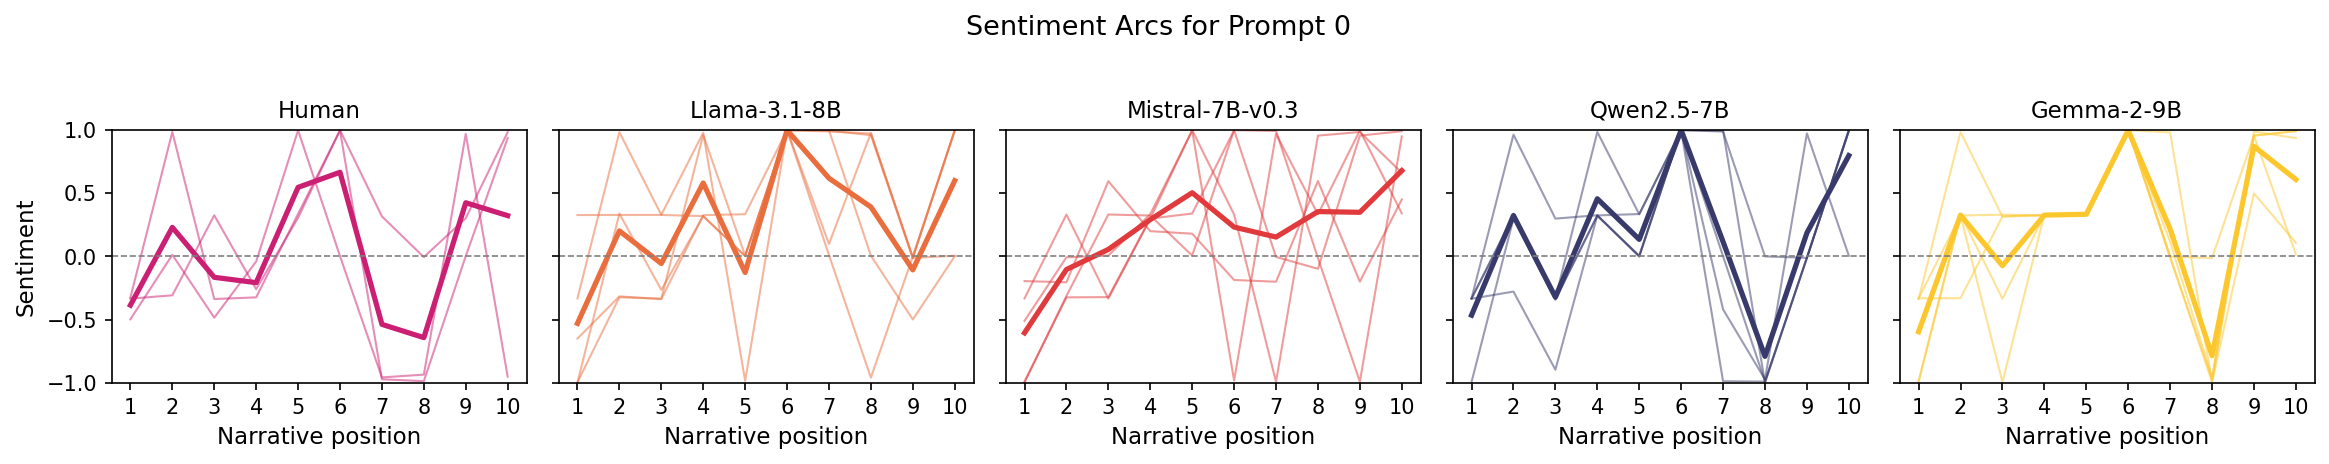

In [64]:
# Show sentiment arcs for one prompt across all sources
example_prompt = df_valid['prompt_id'].iloc[0]
subset = df_valid[df_valid['prompt_id'] == example_prompt]
present_sources = [s for s in SOURCES if s in subset['source'].unique()]

# Plot sentiment arcs for the example prompt
fig, axes = plt.subplots(1, len(present_sources), figsize=(3.15 * len(present_sources), 3), sharey=True)
axes = np.atleast_1d(axes)
x = np.arange(1, ARC_LENGTH + 1)

for ax, source in zip(axes, present_sources):
    label = MODEL_LABELS[source]
    color = MODEL_COLORS[label]
    arcs = subset[subset['source'] == source]['sentiment_arc'].tolist()
    for arc in arcs:
        ax.plot(x, arc, alpha=0.5, color=color, linewidth=1)
    if arcs:
        mean_arc = np.mean(arcs, axis=0)
        ax.plot(x, mean_arc, color=color, linewidth=2.5, label='mean')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Narrative position')
    ax.set_xticks(x)
    ax.set_ylim(-1, 1)

axes[0].set_ylabel('Sentiment')
fig.suptitle(f'Sentiment Arcs for Prompt {example_prompt}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_arcs_example.png', dpi=300, bbox_inches='tight')
plt.show()

## Compute D_narr per Prompt and Source

In [65]:
def mean_pairwise_l2(arcs):
    # Compute mean pairwise Euclidean distance between a list of arc vectors
    # Returns 0.0 if fewer than 2 arcs
    if len(arcs) < 2:
        return 0.0

    # Convert the list of arcs to a NumPy array for efficient computation
    arcs_arr = np.array(arcs)

    # Compute pairwise Euclidean distances between all unique pairs of arcs
    dists = [np.linalg.norm(arcs_arr[i] - arcs_arr[j]) for i, j in combinations(range(len(arcs_arr)), 2)]

    # Return the mean of the pairwise distances
    return np.mean(dists)


# Compute D_narr for each (prompt_id, source) pair
results = []
for (prompt_id, source), group in df_valid.groupby(['prompt_id', 'source']):
    arcs = group['sentiment_arc'].tolist()
    d_narr = mean_pairwise_l2(arcs)
    results.append({'prompt_id': prompt_id, 'source': source, 'n_stories': len(arcs), 'D_narr': d_narr})

df_narr = pd.DataFrame(results)

# Drop groups with too few valid stories: their pairwise diversity is degenerate/undefined
n_before = len(df_narr)
df_narr = df_narr[df_narr['n_stories'] >= MIN_STORIES_PER_GROUP].reset_index(drop=True)
df_narr['model'] = df_narr['source'].map(MODEL_LABELS)

print(f"Dropped {n_before - len(df_narr)} (prompt, source) groups with < {MIN_STORIES_PER_GROUP} valid stories.")
print(f"Computed D_narr for {len(df_narr)} (prompt, source) pairs.")

d_narr_descriptives = df_narr.groupby('source')['D_narr'].describe().round(4)
d_narr_descriptives.to_csv(TABLE_DIR / 'd_narr_descriptives_by_source.csv')
d_narr_descriptives

Dropped 27 (prompt, source) groups with < 2 valid stories.
Computed D_narr for 955 (prompt, source) pairs.


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
gemma,194.0,1.9241,0.7908,0.0111,1.3916,1.9275,2.3957,4.2297
human,186.0,2.7289,0.8614,0.0306,2.1604,2.7318,3.2555,4.9087
llama,198.0,2.0818,0.7555,0.0120,1.5741,2.1167,2.5704,3.6972
mistral,199.0,1.9919,0.7202,0.0064,1.5053,2.0183,2.3511,3.6868
qwen,178.0,2.0001,0.7880,0.0055,1.5084,1.9573,2.4057,4.9616


## Parameter Choice and Sensitivity Analysis

The main specification uses `K = 10` narrative positions and requires at least
10 sentences per text.

Sensitivity to the minimum-length requirement is assessed separately using
`MIN_SENTENCES = 8, 10, 15`, while keeping `K = 10` fixed.


In [66]:
# Shared helpers: re-bin cached sentiment -> D_narr per (prompt, source), then summarise.
def dnarr_by_group(df_sent, min_sentences, arc_length, min_stories=MIN_STORIES_PER_GROUP):
    dv = build_arcs(df_sent, min_sentences, arc_length)
    rows = []

    # Compute D_narr for each (prompt_id, source) pair
    for (pid, src), g in dv.groupby(['prompt_id', 'source']):
        arcs = g['sentiment_arc'].tolist()

        # Filter out groups with too few valid stories: their pairwise diversity is degenerate/undefined
        if len(arcs) < min_stories:
            continue
        
        rows.append({'prompt_id': pid, 'source': src, 'D_narr': mean_pairwise_l2(arcs)})
    return dv, pd.DataFrame(rows)


def summarise(dv, res, **params):
    row = dict(params)
    row['valid_texts'] = len(dv)
    row['valid_groups'] = len(res)
    means = res.groupby('source')['D_narr'].mean() if len(res) else pd.Series(dtype=float)
    for s in SOURCES:
        row[f'mean_D_narr[{s}]'] = round(float(means.get(s, np.nan)), 4)
    return row

In [67]:
# Sensitivity: MIN_SENTENCES (ARC_LENGTH fixed at the main-analysis value)
sens_rows = [
    summarise(*dnarr_by_group(df_sent, ms, ARC_LENGTH), MIN_SENTENCES=ms, ARC_LENGTH=ARC_LENGTH)
    for ms in MIN_SENTENCES_GRID
]
sens_min_sentences = pd.DataFrame(sens_rows)
sens_min_sentences.to_csv(TABLE_DIR / 'sensitivity_min_sentences.csv', index=False)
print(f"Sensitivity to MIN_SENTENCES  (ARC_LENGTH = {ARC_LENGTH}; main analysis: MIN_SENTENCES = {MIN_SENTENCES})")
sens_min_sentences

Sensitivity to MIN_SENTENCES  (ARC_LENGTH = 10; main analysis: MIN_SENTENCES = 10)


,MIN_SENTENCES,ARC_LENGTH,valid_texts,valid_groups,mean_D_narr[human],mean_D_narr[llama],mean_D_narr[mistral],mean_D_narr[qwen],mean_D_narr[gemma]
0,8,10,4372,972,2.7397,2.0867,1.9967,1.9994,1.9310
1,10,10,4252,955,2.7289,2.0818,1.9919,2.0001,1.9241
2,15,10,2506,574,2.3827,1.9586,1.9440,1.8118,1.8594


### Sentence-Length Coverage 

In [68]:
# Retention: texts surviving each sentence-count threshold, by source
SENTENCE_THRESHOLDS = list(range(5, 16))

# Main analysis set = texts meeting the main-analysis MIN_SENTENCES cutoff -> the 100% baseline
_main_kept = df_sent[df_sent['n_sentences'] >= MIN_SENTENCES]
_n_main_texts = len(_main_kept)
_n_main_groups = int((_main_kept.groupby(['prompt_id', 'source']).size() >= MIN_STORIES_PER_GROUP).sum())

# Compute retention stats for each threshold
_ret = []
for thr in SENTENCE_THRESHOLDS:
    kept = df_sent[df_sent['n_sentences'] >= thr]
    grp_sizes = kept.groupby(['prompt_id', 'source']).size()
    n_groups = int((grp_sizes >= MIN_STORIES_PER_GROUP).sum())
    row = {'min_sentences': thr}
    for s in SOURCES:
        row[s] = int((kept['source'] == s).sum())
    row['total_texts'] = len(kept)
    row['pct_of_corpus'] = round(100 * len(kept) / len(df_sent), 1)
    row['valid_groups'] = n_groups
    _ret.append(row)

retention_by_min_sentences = pd.DataFrame(_ret).set_index('min_sentences')
retention_by_min_sentences.to_csv(TABLE_DIR / 'retention_by_min_sentences.csv')
print(f"Texts retained per MIN_SENTENCES threshold  (main analysis set: {_n_main_texts} texts, "
      f"{_n_main_groups} valid prompt-source groups at MIN_SENTENCES = {MIN_SENTENCES})")
retention_by_min_sentences


Texts retained per MIN_SENTENCES threshold  (main analysis set: 4252 texts, 955 valid prompt-source groups at MIN_SENTENCES = 10)


,human,llama,mistral,qwen,gemma,total_texts,pct_of_corpus,valid_groups
min_sentences,,,,,,,,
5,668,991,973,834,934,4400,99.9,977
6,667,991,973,834,933,4398,99.9,977
7,661,991,973,833,932,4390,99.7,975
8,648,990,972,832,930,4372,99.3,972
9,633,989,972,830,922,4346,98.7,969
10,605,971,962,810,904,4252,96.6,955
11,553,896,899,755,840,3943,89.6,893
12,507,787,804,681,755,3534,80.3,808
13,465,705,730,601,676,3177,72.2,728


## Diversity Profile D(t): Where in the Narrative Does Diversity Occur?

- D_narr collapses the full 10-point sentiment arc into a single pairwise distance per (prompt, source) group
- Hides where along the narrative the arcs actually diverge (two groups could have the same D_narr while diverging at completely different points in the story)
- Define a per-position diversity profile
$$D(t) = \frac{1}{\binom{n}{2}} \sum_{i<j} (a_i^{(t)} - a_j^{(t)})^2$$
- $\sum_t D(t)$ exactly equals the mean pairwise squared arc distance

In [69]:
def position_wise_diversity(arcs):
    # Mean pairwise squared difference at each narrative position.
    # Returns np.array of shape (ARC_LENGTH,), or None if fewer than 2 arcs.
    arcs_arr = np.array(arcs)

    # Return None if fewer than 2 arcs (pairwise diversity is undefined)
    if len(arcs_arr) < 2:
        return None

    # Compute pairwise squared differences for each narrative position
    diffs_sq = np.array([(arcs_arr[i] - arcs_arr[j]) ** 2 for i, j in combinations(range(len(arcs_arr)), 2)])

    # Return the mean of the pairwise squared differences at each position
    return diffs_sq.mean(axis=0)


# Compute diversity profile D(t) for each (prompt_id, source) pair
profile_results = []
for (prompt_id, source), group in df_valid.groupby(['prompt_id', 'source']):
    arcs = group['sentiment_arc'].tolist()
    profile = position_wise_diversity(arcs)
    if profile is None:
        continue
    profile_results.append({'prompt_id': prompt_id, 'source': source, 'profile': profile, 'n_stories': len(arcs)})

df_profile = pd.DataFrame(profile_results)

# Same degenerate-group filter as for D_narr (mean pairwise L2 distance): drop (prompt, source) groups with too few valid stories
n_before = len(df_profile)
df_profile = df_profile[df_profile['n_stories'] >= MIN_STORIES_PER_GROUP].reset_index(drop=True)


print(f"Dropped {n_before - len(df_profile)} (prompt, source) groups with < {MIN_STORIES_PER_GROUP} valid stories.")
print(f"Computed diversity profiles for {len(df_profile)} (prompt, source) pairs.")

Dropped 0 (prompt, source) groups with < 2 valid stories.
Computed diversity profiles for 955 (prompt, source) pairs.


In [70]:
# Sanity check: sum_t D(t) must equal the mean pairwise squared arc distance
def mean_pairwise_sq_l2(arcs):
    arcs_arr = np.array(arcs)

    # Return np.nan if fewer than 2 arcs (pairwise diversity is undefined)
    if len(arcs_arr) < 2:
        return np.nan

    # Compute pairwise squared L2 distances between all unique pairs of arcs
    dists_sq = [np.sum((arcs_arr[i] - arcs_arr[j]) ** 2) for i, j in combinations(range(len(arcs_arr)), 2)]
    return np.mean(dists_sq)

# Compute mean pairwise squared L2 distance for each (prompt_id, source) pair
check = (
    df_valid.groupby(['prompt_id', 'source'])['sentiment_arc']
    .apply(lambda g: mean_pairwise_sq_l2(g.tolist()))
    .reset_index(name='mean_sq_l2')
)


df_profile = df_profile.merge(check, on=['prompt_id', 'source'])
df_profile['sum_profile'] = df_profile['profile'].apply(np.sum)
df_profile['D_narr_rms'] = np.sqrt(df_profile['sum_profile'])

max_diff = (df_profile['sum_profile'] - df_profile['mean_sq_l2']).abs().max()
print(f"Decomposition check: max |sum_t D(t) - mean pairwise squared L2| = {max_diff:.2e}")

# Compare the RMS variant to the originally reported (non-squared) D_narr
comparison = df_profile.merge(df_narr, on=['prompt_id', 'source'])
r_check = np.corrcoef(comparison['D_narr'], comparison['D_narr_rms'])[0, 1]


print(f"\nD_narr (reported) vs. D_narr_rms (sqrt of decomposed profile): r = {r_check:.3f}")
print(comparison[['D_narr', 'D_narr_rms']].describe().round(4))

Decomposition check: max |sum_t D(t) - mean pairwise squared L2| = 5.33e-15

D_narr (reported) vs. D_narr_rms (sqrt of decomposed profile): r = 0.992
         D_narr  D_narr_rms
count  955.0000    955.0000
mean     2.1418      2.2447
std      0.8350      0.8245
min      0.0055      0.0060
25%      1.5820      1.6822
50%      2.0974      2.2193
75%      2.6690      2.7720
max      4.9616      4.9616


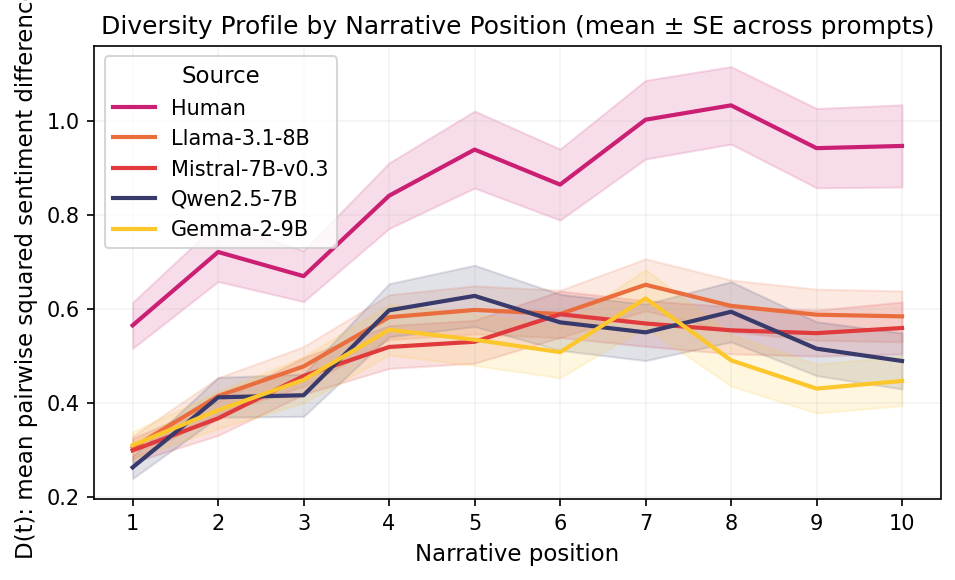

In [71]:
# Plot: diversity profile D(t) by narrative position, per source (mean +/- SE across prompts)
x = np.arange(1, ARC_LENGTH + 1)

fig, ax = plt.subplots(figsize=(6.5, 4))
for source in SOURCES:
    sub = df_profile[df_profile['source'] == source]
    if sub.empty:
        continue
    profiles = np.array(sub['profile'].tolist())
    mean_profile = profiles.mean(axis=0)
    se_profile = profiles.std(axis=0) / np.sqrt(len(profiles))
    label = MODEL_LABELS[source]
    color = MODEL_COLORS[label]
    ax.plot(x, mean_profile, label=label, color=color, linewidth=2)
    ax.fill_between(x, mean_profile - se_profile, mean_profile + se_profile, alpha=0.15, color=color)

ax.set_xlabel('Narrative position')
ax.set_xticks(x)
ax.set_ylabel('D(t): mean pairwise squared sentiment difference')
ax.set_title('Diversity Profile by Narrative Position (mean ± SE across prompts)', fontsize=12)
ax.legend(title='Source')
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_profile_by_position.png', dpi=300, bbox_inches='tight')
plt.show()

In [72]:
# Export: diversity profile D(t) (mean +/- SE across prompts) by narrative position, per source
profile_export_rows = []
for source in SOURCES:
    sub = df_profile[df_profile['source'] == source]
    if sub.empty:
        continue
    profiles = np.array(sub['profile'].tolist())
    mean_profile = profiles.mean(axis=0)
    se_profile = profiles.std(axis=0) / np.sqrt(len(profiles))
    for pos, m, se in zip(x, mean_profile, se_profile):
        profile_export_rows.append({'source': source, 'position': pos, 'mean_D': m, 'se_D': se})

pd.DataFrame(profile_export_rows).to_csv(TABLE_DIR / 'diversity_profile_by_position.csv', index=False)


In [73]:
# Where in the story is diversity concentrated?
position_labels = np.arange(1, ARC_LENGTH + 1)
third = ARC_LENGTH // 3

print('Narrative position of maximum diversity by source:')
for source in SOURCES:
    sub = df_profile[df_profile['source'] == source]
    if sub.empty:
        continue
    profiles = np.array(sub['profile'].tolist())
    mean_profile = profiles.mean(axis=0)
    peak_idx = np.argmax(mean_profile)
    print(f'  {MODEL_LABELS[source]:18s}: peak at position {position_labels[peak_idx]}  (D(t)={mean_profile[peak_idx]:.4f})')

print()
print('Diversity in the first third (setup) vs. last third (resolution) of the story:')
for source in SOURCES:
    sub = df_profile[df_profile['source'] == source]
    if sub.empty:
        continue
    profiles = np.array(sub['profile'].tolist())
    mean_profile = profiles.mean(axis=0)
    early = mean_profile[:third].mean()
    late = mean_profile[-third:].mean()
    print(f'  {MODEL_LABELS[source]:18s}: early={early:.4f}, late={late:.4f}, ratio(early/late)={early / late:.2f}')

Narrative position of maximum diversity by source:
  Human             : peak at position 8  (D(t)=1.0328)
  Llama-3.1-8B      : peak at position 7  (D(t)=0.6512)
  Mistral-7B-v0.3   : peak at position 6  (D(t)=0.5885)
  Qwen2.5-7B        : peak at position 5  (D(t)=0.6275)
  Gemma-2-9B        : peak at position 7  (D(t)=0.6223)

Diversity in the first third (setup) vs. last third (resolution) of the story:
  Human             : early=0.6518, late=0.9737, ratio(early/late)=0.67
  Llama-3.1-8B      : early=0.3989, late=0.5926, ratio(early/late)=0.67
  Mistral-7B-v0.3   : early=0.3744, late=0.5540, ratio(early/late)=0.68
  Qwen2.5-7B        : early=0.3636, late=0.5327, ratio(early/late)=0.68
  Gemma-2-9B        : early=0.3811, late=0.4559, ratio(early/late)=0.84


## Descriptive Analysis

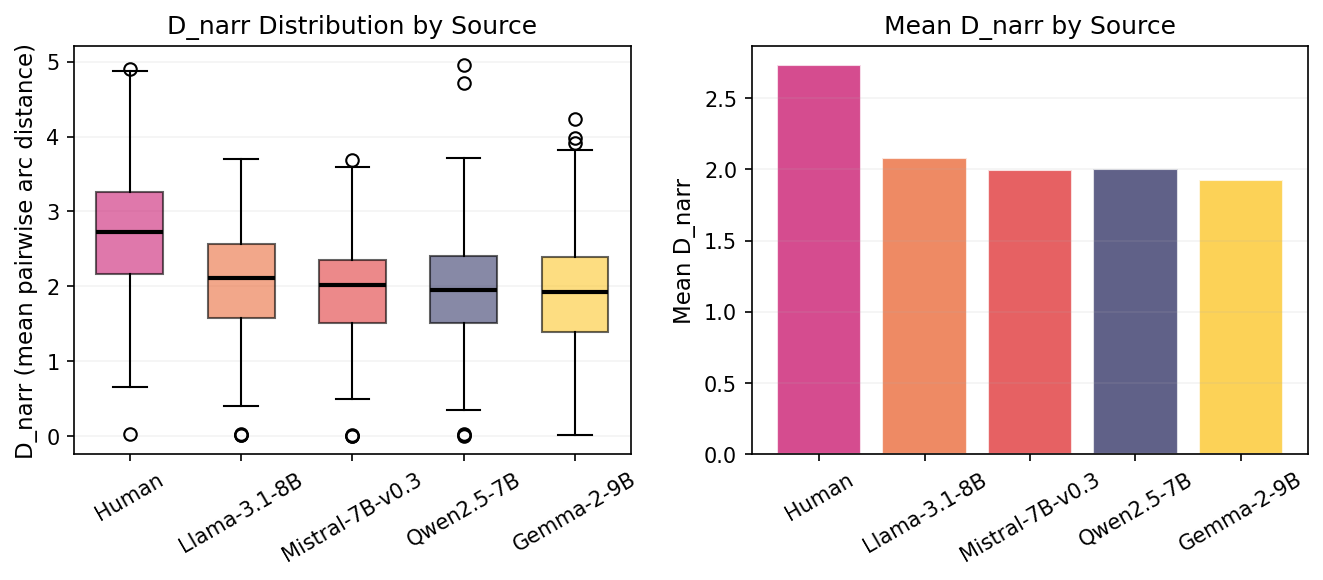

,mean,std
Human,2.7289,0.8614
Llama-3.1-8B,2.0818,0.7555
Mistral-7B-v0.3,1.9919,0.7202
Qwen2.5-7B,2.0001,0.7880
Gemma-2-9B,1.9241,0.7908


In [74]:
# D_narr by source
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

source_order = df_narr.groupby('source')['D_narr'].median().sort_values(ascending=False).index.tolist()
label_order = [MODEL_LABELS[s] for s in source_order]
colors_order = [MODEL_COLORS[l] for l in label_order]

data = [df_narr[df_narr['source'] == s]['D_narr'].values for s in source_order]
bp = axes[0].boxplot(data, labels=label_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2), widths=0.6)
for patch, color in zip(bp['boxes'], colors_order):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title('D_narr Distribution by Source', fontsize=12)
axes[0].set_ylabel('D_narr (mean pairwise arc distance)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.15, axis='y')

means = df_narr.groupby('source')['D_narr'].mean().reindex(source_order)
axes[1].bar(label_order, means.values, color=colors_order, edgecolor='white', alpha=0.8)
axes[1].set_title('Mean D_narr by Source', fontsize=12)
axes[1].set_ylabel('Mean D_narr')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'narrative_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

d_narr_mean_std = df_narr.groupby('source')['D_narr'].agg(['mean', 'std']).reindex(source_order).round(4)
d_narr_mean_std.index = label_order
d_narr_mean_std.to_csv(TABLE_DIR / 'd_narr_mean_std_by_source.csv')
d_narr_mean_std

## Mean Sentiment Arcs per Source (Aggregate)

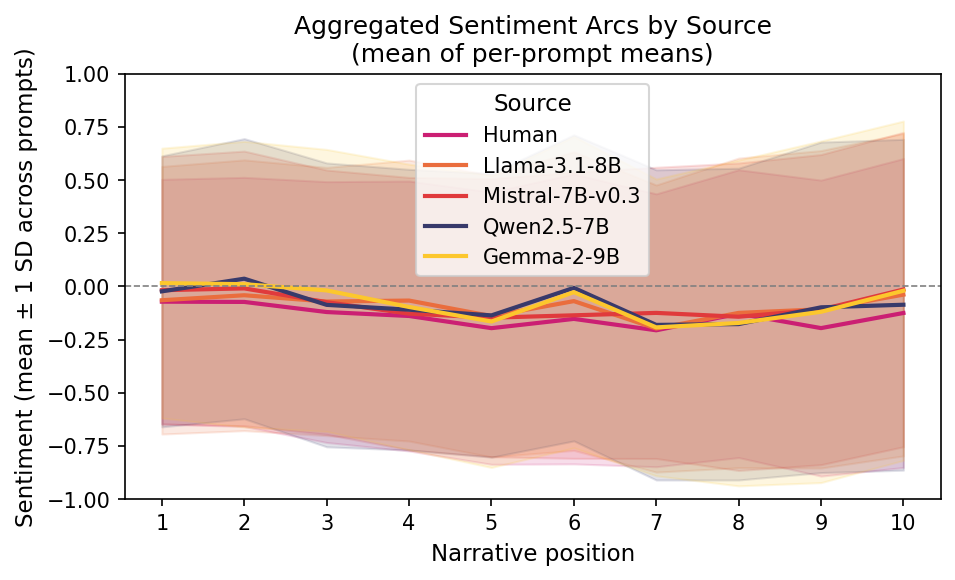

In [75]:
fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(1, ARC_LENGTH + 1)

for source in SOURCES:
    sub = df_valid[df_valid['source'] == source]
    if sub.empty:
        continue
    # Mean arc per prompt first (over its texts), then mean/std across prompts --
    # avoids prompts with more texts dominating the aggregate
    per_prompt_arcs = np.array([
        np.mean(g['sentiment_arc'].tolist(), axis=0)
        for _, g in sub.groupby('prompt_id')
    ])
    mean_arc = per_prompt_arcs.mean(axis=0)
    std_arc = per_prompt_arcs.std(axis=0)
    label = MODEL_LABELS[source]
    color = MODEL_COLORS[label]
    ax.plot(x, mean_arc, label=label, color=color, linewidth=2)
    ax.fill_between(x, mean_arc - std_arc, mean_arc + std_arc, alpha=0.15, color=color)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Narrative position')
ax.set_xticks(x)
ax.set_ylabel('Sentiment (mean ± 1 SD across prompts)')
ax.set_title('Aggregated Sentiment Arcs by Source\n(mean of per-prompt means)', fontsize=12)
ax.legend(title='Source')
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'aggregated_sentiment_arcs.png', dpi=300, bbox_inches='tight')
plt.show()

In [76]:
# Export: aggregated sentiment arc (mean +/- SD across prompts) by narrative position, per source
sentiment_export_rows = []
for source in SOURCES:
    sub = df_valid[df_valid['source'] == source]
    if sub.empty:
        continue
    per_prompt_arcs = np.array([
        np.mean(g['sentiment_arc'].tolist(), axis=0)
        for _, g in sub.groupby('prompt_id')
    ])
    mean_arc = per_prompt_arcs.mean(axis=0)
    std_arc = per_prompt_arcs.std(axis=0)
    for pos, m, sd in zip(x, mean_arc, std_arc):
        sentiment_export_rows.append({'source': source, 'position': pos, 'mean_sentiment': m, 'std_sentiment': sd})

pd.DataFrame(sentiment_export_rows).to_csv(TABLE_DIR / 'aggregated_sentiment_arcs.csv', index=False)


## Diversity Gap (Human, Model)

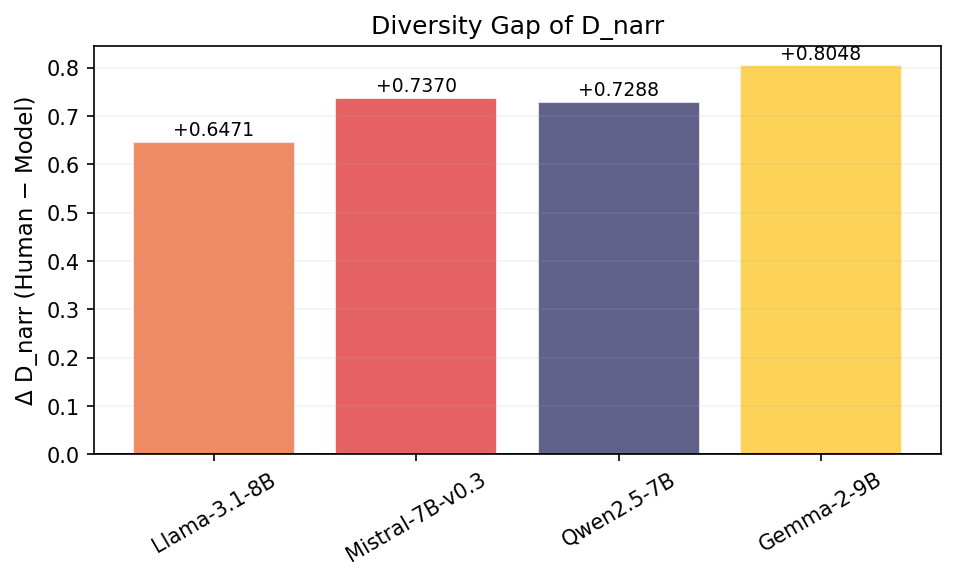


Diversity Gap (Human − Model):
  Llama-3.1-8B      : +0.6471
  Mistral-7B-v0.3   : +0.7370
  Qwen2.5-7B        : +0.7288
  Gemma-2-9B        : +0.8048


In [77]:
human_mean = df_narr[df_narr['source'] == 'human']['D_narr'].mean()
present_sources = [s for s in SOURCES if s in df_narr['source'].unique()]
llm_sources = [s for s in present_sources if s != 'human']
llm_labels = [MODEL_LABELS[s] for s in llm_sources]

# Compute the diversity gap (Δ D_narr) between human and each model
deltas = [human_mean - df_narr[df_narr['source'] == s]['D_narr'].mean() for s in llm_sources]
colors_gap = [MODEL_COLORS[l] for l in llm_labels]

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(llm_labels, deltas, color=colors_gap, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Δ D_narr (Human − Model)')
ax.set_title('Diversity Gap of D_narr', fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')

for bar, delta in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width() / 2, delta + (0.005 if delta >= 0 else -0.012),
            f'{delta:+.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_gap_human_model.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nDiversity Gap (Human − Model):')
for l, d in zip(llm_labels, deltas):
    print(f'  {l:18s}: {d:+.4f}')

pd.DataFrame({'model': llm_labels, 'delta_D_narr': deltas}).to_csv(TABLE_DIR / 'd_narr_diversity_gap.csv', index=False)

## Export Results

In [78]:
out_path = TABLE_DIR / 'D_narr_results.csv'
df_narr.to_csv(out_path, index=False)
print(f"Saved D_narr results to: {out_path}")
df_narr.head(10)

Saved D_narr results to: ../../metrics/03_narrative_diversity/tables/translation_ref3/D_narr_results.csv


,prompt_id,source,n_stories,D_narr,model
0,0,gemma,5,1.613086,Gemma-2-9B
1,0,human,3,2.608128,Human
2,0,llama,5,2.181202,Llama-3.1-8B
3,0,mistral,5,2.456043,Mistral-7B-v0.3
4,0,qwen,5,1.920171,Qwen2.5-7B
5,1,gemma,5,0.694487,Gemma-2-9B
6,1,human,4,2.893260,Human
7,1,llama,5,2.558623,Llama-3.1-8B
8,1,mistral,5,1.344007,Mistral-7B-v0.3
9,1,qwen,5,2.052675,Qwen2.5-7B


# Appendix: Arc-Shape-Classification

k-means with k=6 on all sentiment-arcs using the six basic forms of emotional arcs (Reagan et al., 2016): *Rags to Riches*, *Tragedy*, *Man in a Hole*, *Icarus*, *Cinderella*, *Oedipus*

### Validating the Choice of k

check whether k=6 is actually well-supported by this dataset's own clustering structure:
1. Elbow method: inertia -> always decreases with k, requires a subjective visual judgment of where returns diminish
2. Silhouette score: mean, over all points, of how much closer each point is to its own cluster than to the next-best cluster,  ranges [-1, 1], forms an actual maximum rather than a subjective bend

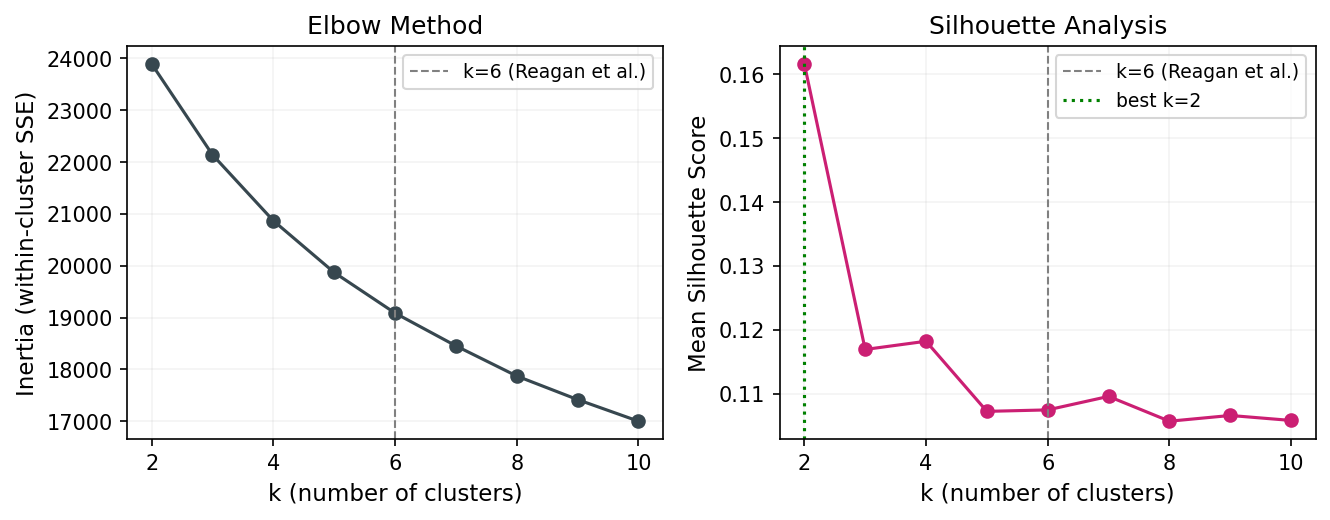

k, inertia, silhouette:
  k= 2: inertia=  23892.15, silhouette=0.1616
  k= 3: inertia=  22139.50, silhouette=0.1169
  k= 4: inertia=  20868.52, silhouette=0.1182
  k= 5: inertia=  19870.32, silhouette=0.1072
  k= 6: inertia=  19087.58, silhouette=0.1074
  k= 7: inertia=  18455.38, silhouette=0.1096
  k= 8: inertia=  17874.01, silhouette=0.1057
  k= 9: inertia=  17419.61, silhouette=0.1066
  k=10: inertia=  17002.91, silhouette=0.1058


In [79]:
arc_matrix_check = np.array(df_valid['sentiment_arc'].tolist())

# KMeans clustering validation: elbow method and silhouette analysis
k_range = list(range(2, 11))
inertias = []
silhouettes = []

# Fit KMeans for each k and compute inertia and silhouette score
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(arc_matrix_check)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(arc_matrix_check, labels))

best_k = k_range[int(np.argmax(silhouettes))]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

axes[0].plot(k_range, inertias, marker='o', color='#37474F')
axes[0].axvline(6, color='gray', linestyle='--', linewidth=1, label='k=6 (Reagan et al.)')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.15)

axes[1].plot(k_range, silhouettes, marker='o', color='#cb1f73')
axes[1].axvline(6, color='gray', linestyle='--', linewidth=1, label='k=6 (Reagan et al.)')
axes[1].axvline(best_k, color='green', linestyle=':', linewidth=1.5, label=f'best k={best_k}')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_title('Silhouette Analysis', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_k_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print('k, inertia, silhouette:')
for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f'  k={k:2d}: inertia={inertia:10.2f}, silhouette={sil:.4f}')

In [80]:
# Arc-Matrix from all valid stories: each row is a story, each column is a point in the sentiment arc
arc_matrix = np.array(df_valid['sentiment_arc'].tolist())
df_valid = df_valid.reset_index(drop=True).copy()

# k-means with k=6
N_SHAPES = 6
kmeans = KMeans(n_clusters=N_SHAPES, random_state=42, n_init=20)
kmeans.fit(arc_matrix)
df_valid['arc_shape'] = kmeans.labels_

# Sort cluster by mean sentiment (positive to negative)
centroids = kmeans.cluster_centers_
shape_order = np.argsort(centroids.mean(axis=1))[::-1]
shape_remap = {int(old): int(new) for new, old in enumerate(shape_order)}
df_valid['arc_shape'] = df_valid['arc_shape'].map(shape_remap)
centroids = centroids[shape_order]

print(f'k-means with k={N_SHAPES} on {len(arc_matrix):,} sentiment-arcs')
print(f'\nCluster sizes:')


for i in range(N_SHAPES):
    n = (df_valid['arc_shape'] == i).sum()
    print(f'  Shape {i}: {n:4d} stories ({n / len(df_valid) * 100:.1f}%)')

k-means with k=6 on 4,252 sentiment-arcs

Cluster sizes:
  Shape 0:  690 stories (16.2%)
  Shape 1:  549 stories (12.9%)
  Shape 2:  840 stories (19.8%)
  Shape 3:  595 stories (14.0%)
  Shape 4:  720 stories (16.9%)
  Shape 5:  858 stories (20.2%)


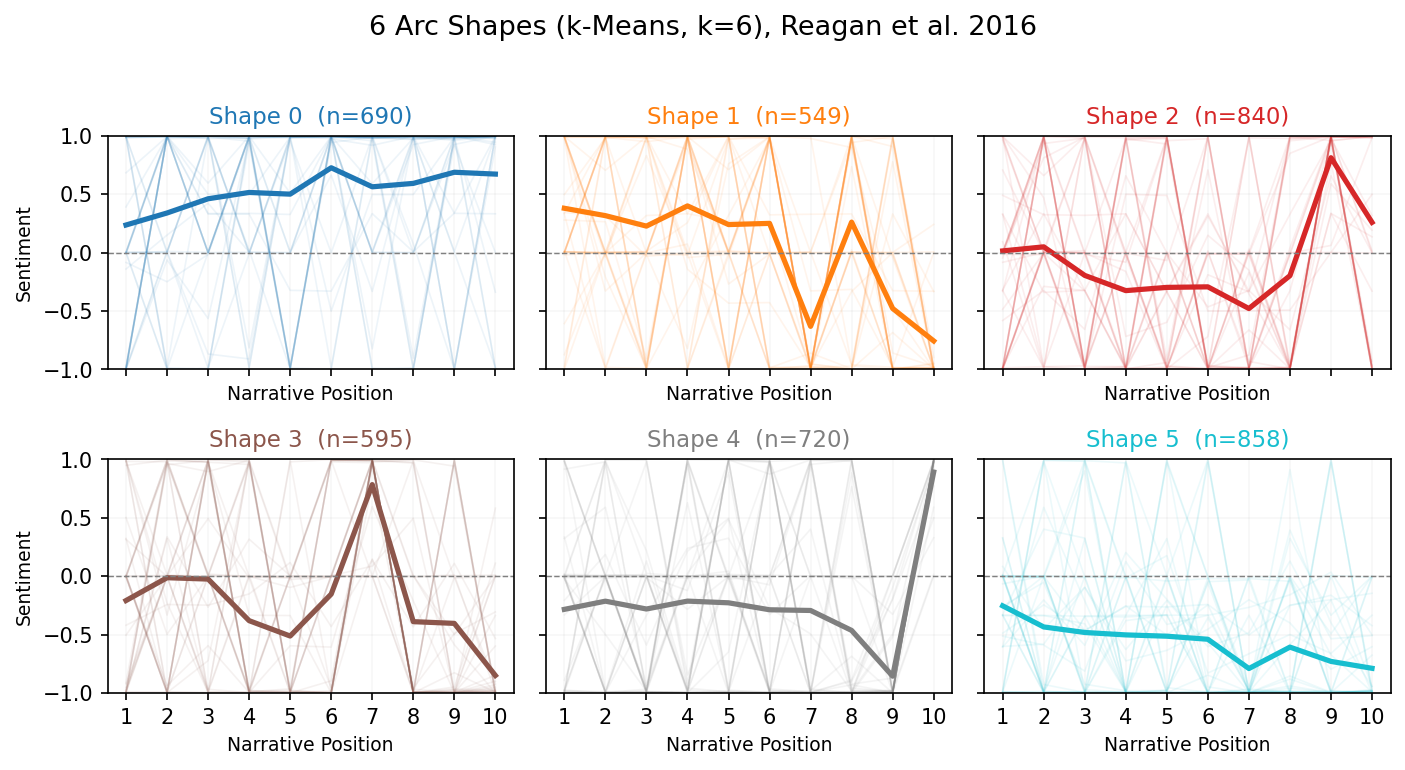

In [81]:
# Visualize 6 arc shapes: centroids + background arcs
SHAPE_COLORS = plt.cm.tab10(np.linspace(0, 0.9, N_SHAPES))
x = np.arange(1, ARC_LENGTH + 1)

fig, axes = plt.subplots(2, 3, figsize=(9.5, 5), sharey=True, sharex=True)
axes = axes.flatten()

# Plot each cluster's arcs and centroid
for i, ax in enumerate(axes):
    mask = df_valid['arc_shape'] == i
    cluster_arcs = arc_matrix[mask.values]
    n_show = min(40, len(cluster_arcs))
    sample_idx = np.random.choice(len(cluster_arcs), n_show, replace=False)


    for arc in cluster_arcs[sample_idx]:
        ax.plot(x, arc, alpha=0.08, color=SHAPE_COLORS[i], linewidth=0.8)

    ax.plot(x, centroids[i], color=SHAPE_COLORS[i], linewidth=2.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_ylim(-1, 1)
    ax.set_title(f'Shape {i}  (n={mask.sum()})', fontsize=11, color=SHAPE_COLORS[i])
    ax.set_xlabel('Narrative Position', fontsize=9)
    ax.set_xticks(x)

    if i % 3 == 0:
        ax.set_ylabel('Sentiment', fontsize=9)
        
    ax.grid(True, alpha=0.1)

fig.suptitle('6 Arc Shapes (k-Means, k=6), Reagan et al. 2016', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'arc_shapes_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

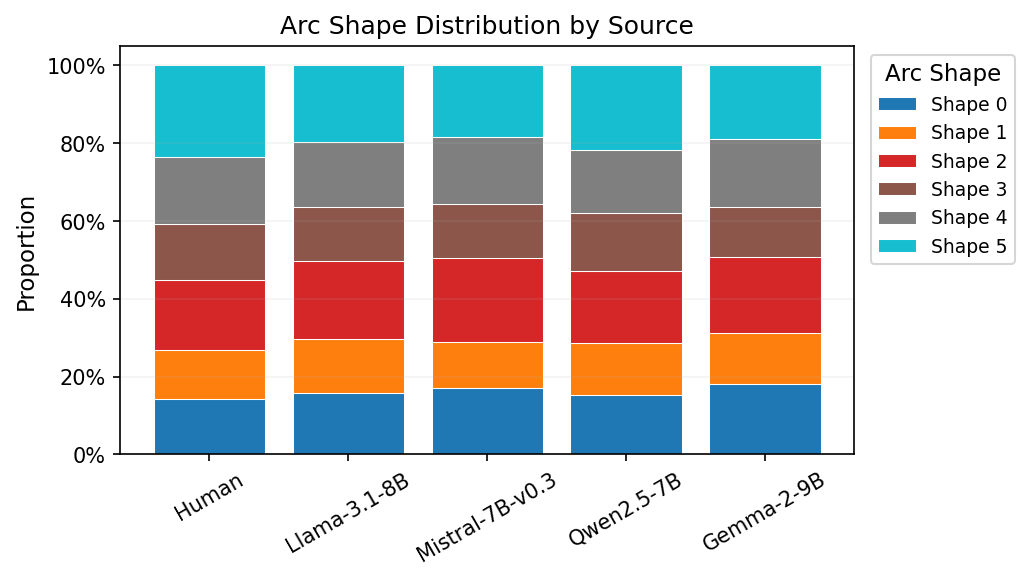

Entropy of arc shape distribution by source:
  (max. at uniform distribution: 2.585 bit)

  Human             : H = 2.552 bit  █████████████████████████
  Llama-3.1-8B      : H = 2.569 bit  █████████████████████████
  Mistral-7B-v0.3   : H = 2.559 bit  █████████████████████████
  Qwen2.5-7B        : H = 2.566 bit  █████████████████████████
  Gemma-2-9B        : H = 2.566 bit  █████████████████████████


In [82]:
# Arc shape distribution by source (stacked bar chart)
shape_dist = df_valid.groupby(['source', 'arc_shape']).size().unstack(fill_value=0)
present_sources = [s for s in SOURCES if s in shape_dist.index]

# Normalize to proportions for stacked bar chart
shape_dist_norm = shape_dist.div(shape_dist.sum(axis=1), axis=0).reindex(present_sources)
present_labels = [MODEL_LABELS[s] for s in present_sources]

fig, ax = plt.subplots(figsize=(7, 4))
bottom = np.zeros(len(present_sources))

# Stacked bar chart: each shape's proportion per source
for i in range(N_SHAPES):
    vals = shape_dist_norm[i].values
    ax.bar(present_labels, vals, bottom=bottom, label=f'Shape {i}',
           color=SHAPE_COLORS[i], edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_ylabel('Proportion')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('Arc Shape Distribution by Source', fontsize=12)
ax.legend(title='Arc Shape', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.15, axis='y')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / 'arc_shape_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Entropy of arc shape distribution by source
print('Entropy of arc shape distribution by source:')
print(f'  (max. at uniform distribution: {np.log2(N_SHAPES):.3f} bit)')
print()

for source in present_sources:
    dist = shape_dist_norm.loc[source].values
    ent = scipy_entropy(dist, base=2)
    bar = '█' * int(ent * 10)
    
    print(f'  {MODEL_LABELS[source]:18s}: H = {ent:.3f} bit  {bar}')

### Which Source Prefers Which Arc Shape?

In [83]:
# Aggregate to one arc-shape per (prompt, source) group to avoid pseudo-replication
group_mean_arcs = (
    df_valid.groupby(['prompt_id', 'source'])['sentiment_arc']
    .apply(lambda g: np.mean(np.array(g.tolist()), axis=0))
)

# Filter out any (prompt, source) groups that don't exist in the original df_narr (e.g., dropped for too few stories)
valid_keys = set(zip(df_narr['prompt_id'], df_narr['source']))
group_mean_arcs = group_mean_arcs[[k in valid_keys for k in group_mean_arcs.index]]

# Compute the arc shape for each (prompt, source) group by predicting the cluster label of the mean arc
mean_arc_matrix = np.stack(group_mean_arcs.values)
mean_labels_raw = kmeans.predict(mean_arc_matrix)
mean_labels = np.array([shape_remap[int(l)] for l in mean_labels_raw])

# Create a DataFrame with the aggregated (prompt, source) groups and their corresponding arc shapes
shape_group = pd.DataFrame({
    'prompt_id': [k[0] for k in group_mean_arcs.index],
    'source': [k[1] for k in group_mean_arcs.index],
    'arc_shape': mean_labels,
})

# Aggregate the arc shape counts by source and arc shape, filling in any missing combinations with zeros
shape_dist_agg = (
    shape_group.groupby(['source', 'arc_shape']).size()
    .unstack(fill_value=0)
    .reindex(index=present_sources, columns=range(N_SHAPES), fill_value=0)
)

print(f"Aggregated {len(df_valid)} individual stories -> {len(shape_group)} (prompt, source) groups.")
print(shape_dist_agg.rename(index=MODEL_LABELS))

# --- Significance testing removed: chi-square test of independence / Cramer's V
# dropped. Expected counts under independence (row_total * col_total / grand_total)
# are kept since the standardized-residuals heatmap below is descriptive, not a
# significance test -- it shows over-/under-representation relative to chance. ---
row_totals = shape_dist_agg.values.sum(axis=1, keepdims=True)
col_totals = shape_dist_agg.values.sum(axis=0, keepdims=True)
expected_agg = row_totals * col_totals / shape_dist_agg.values.sum()

# Standardized residuals on the aggregated table: (observed - expected) / sqrt(expected)
# Positive = source uses this shape more than chance, negative = less

std_resid = (shape_dist_agg.values - expected_agg) / np.sqrt(expected_agg)
df_resid = pd.DataFrame(std_resid, index=[MODEL_LABELS[s] for s in shape_dist_agg.index], columns=shape_dist_agg.columns)
df_resid.columns = [f'Shape {i}' for i in df_resid.columns]
df_resid.to_csv(TABLE_DIR / 'arc_shape_standardized_residuals.csv')

print("\nStandardized residuals (source x shape), prompt-level aggregated:")
print(df_resid.round(2))

Aggregated 4252 individual stories -> 955 (prompt, source) groups.
arc_shape         0   1   2   3   4   5
source                                 
Human            28  25  42  18  24  49
Llama-3.1-8B     29  33  38  25  27  46
Mistral-7B-v0.3  38  19  45  23  34  40
Qwen2.5-7B       32  23  34  27  22  40
Gemma-2-9B       36  23  38  26  28  43

Standardized residuals (source x shape), prompt-level aggregated:
                 Shape 0  Shape 1  Shape 2  Shape 3  Shape 4  Shape 5
Human              -0.66     0.21     0.59    -1.08    -0.45     1.00
Llama-3.1-8B       -0.82     1.48    -0.45     0.07    -0.19     0.12
Mistral-7B-v0.3     0.69    -1.31     0.62    -0.36     1.11    -0.81
Qwen2.5-7B          0.29     0.02    -0.45     1.02    -0.63    -0.10
Gemma-2-9B          0.50    -0.40    -0.32     0.37     0.11    -0.19


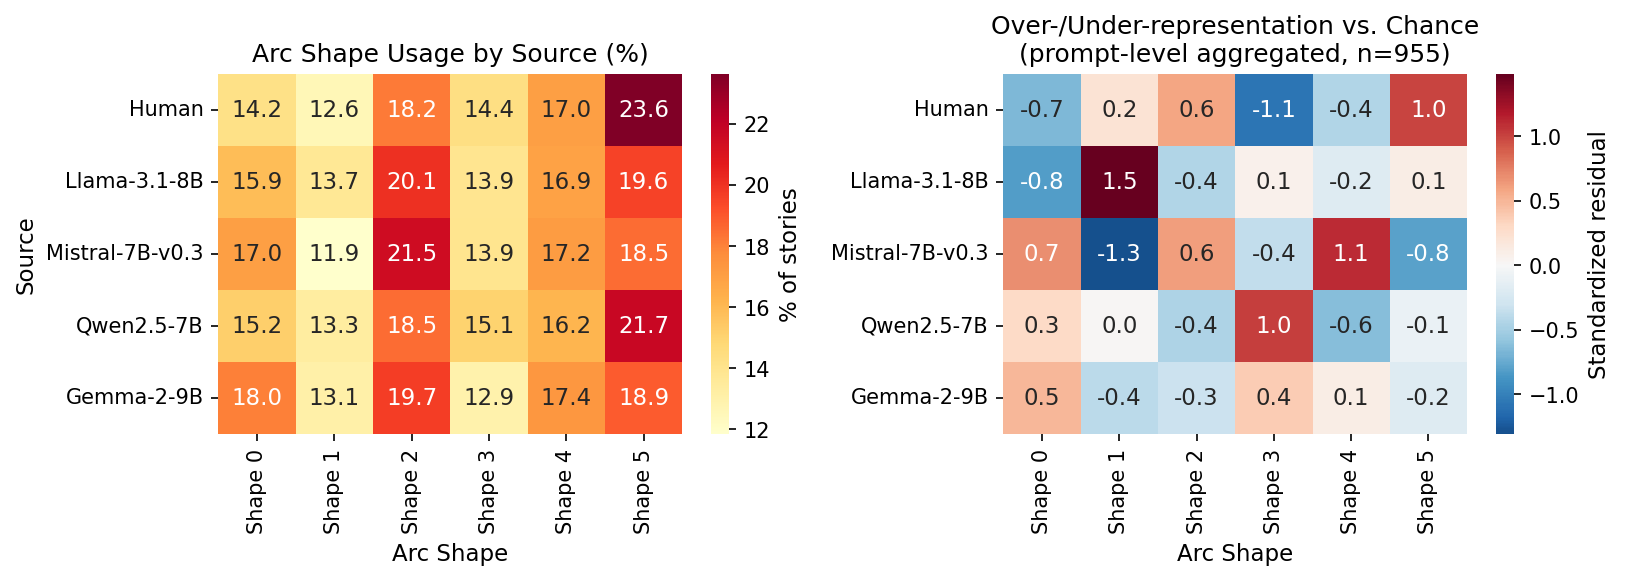

In [84]:
# Heatmaps: usage share and over-/under-representation vs. chance
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(shape_dist_norm.rename(index=MODEL_LABELS) * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% of stories'}, ax=axes[0],
            xticklabels=[f'Shape {i}' for i in range(N_SHAPES)])
axes[0].set_title('Arc Shape Usage by Source (%)', fontsize=12)
axes[0].set_xlabel('Arc Shape')
axes[0].set_ylabel('Source')

sns.heatmap(df_resid, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Standardized residual'}, ax=axes[1])
axes[1].set_title(f'Over-/Under-representation vs. Chance\n(prompt-level aggregated, n={int(shape_dist_agg.values.sum())})', fontsize=12)
axes[1].set_xlabel('Arc Shape')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIG_DIR / 'arc_shape_source_association.png', dpi=300, bbox_inches='tight')
plt.show()

In [85]:
# Dominant arc shape per source
print('Dominant arc shape per source:')
print(f'{"Source":18s} {"Dominant Shape":>15} {"Share":>8} {"vs. chance (16.7%)":>20}')
print('-' * 65)

for source in present_sources:
    dist = shape_dist_norm.loc[source]
    dominant = dist.idxmax()
    share = dist.max()
    delta_pp = (share - 1 / N_SHAPES) * 100
    
    print(f'{MODEL_LABELS[source]:18s} {"Shape " + str(dominant):>15} {share * 100:>7.1f}% {delta_pp:>+19.1f}pp')

Dominant arc shape per source:
Source              Dominant Shape    Share   vs. chance (16.7%)
-----------------------------------------------------------------
Human                      Shape 5    23.6%                +7.0pp
Llama-3.1-8B               Shape 2    20.1%                +3.4pp
Mistral-7B-v0.3            Shape 2    21.5%                +4.9pp
Qwen2.5-7B                 Shape 5    21.7%                +5.1pp
Gemma-2-9B                 Shape 2    19.7%                +3.0pp


# Appendix: VADER-based Sentiment Arcs (for Reference)

The analysis above uses a transformer-based sentiment classifier (`siebert/sentiment-roberta-large-english`) as its sentiment signal (unless `SENTIMENT_METHOD = 'vader'` above) -> this appendix runs the original VADER-based pipeline on the same texts and compares its D_narr against the transformer-based D_narr reported above.

In [86]:
# Recompute sentiment arcs with VADER (original lexicon-based approach) for reference
vader_analyzer = SentimentIntensityAnalyzer()

def get_sentiment_arc_vader(text, arc_length=ARC_LENGTH, min_sentences=MIN_SENTENCES):
    # Compute sentiment arc using VADER sentiment analysis
    sentences = [s.strip() for s in sent_tokenize(text) if s.strip()]

    # Check if there are enough sentences
    if len(sentences) < min_sentences:
        return None

    # Compute sentiment scores for each sentence using VADER
    scores = [vader_analyzer.polarity_scores(s)['compound'] for s in sentences]
    return bin_to_arc(scores, arc_length)

df['sentiment_arc_vader'] = df['text'].apply(get_sentiment_arc_vader)
df_valid_vader = df.dropna(subset=['sentiment_arc_vader']).copy()

print(f"Valid VADER arcs: {len(df_valid_vader)}")

Valid VADER arcs: 4252


In [87]:
# D_narr with VADER arcs
results_vader = []

# Compute D_narr for each (prompt_id, source) pair using VADER arcs
for (prompt_id, source), group in df_valid_vader.groupby(['prompt_id', 'source']):
    arcs = group['sentiment_arc_vader'].tolist()
    d_narr = mean_pairwise_l2(arcs)
    results_vader.append({'prompt_id': prompt_id, 'source': source, 'n_stories': len(arcs), 'D_narr_vader': d_narr})

# Create a DataFrame for the VADER results and filter out groups with too few stories
df_narr_vader = pd.DataFrame(results_vader)
df_narr_vader = df_narr_vader[df_narr_vader['n_stories'] >= MIN_STORIES_PER_GROUP].reset_index(drop=True)

print("D_narr (VADER) by source:")
print(df_narr_vader.groupby('source')['D_narr_vader'].describe().round(4))

# Compare D_narr from transformer-based arcs vs. VADER arcs
comparison_vader = df_narr.merge(df_narr_vader, on=['prompt_id', 'source'])
r_vader = np.corrcoef(comparison_vader['D_narr'], comparison_vader['D_narr_vader'])[0, 1]

print(f"\nCorrelation D_narr (transformer) <-> D_narr (VADER): r = {r_vader:.3f}")

comparison_vader.to_csv(TABLE_DIR / 'd_narr_transformer_vs_vader.csv', index=False)

D_narr (VADER) by source:
         count    mean     std     min     25%     50%     75%     max
source                                                                
gemma    194.0  0.7941  0.3477  0.1606  0.5422  0.7469  0.9886  2.2488
human    186.0  1.2151  0.3890  0.1773  0.9140  1.1856  1.5029  2.3718
llama    198.0  0.8685  0.3436  0.1644  0.6122  0.8449  1.0526  1.9758
mistral  199.0  0.8066  0.3015  0.0508  0.5850  0.7708  1.0137  1.8108
qwen     178.0  0.8112  0.2976  0.1267  0.6237  0.7914  0.9786  1.5803

Correlation D_narr (transformer) <-> D_narr (VADER): r = 0.623


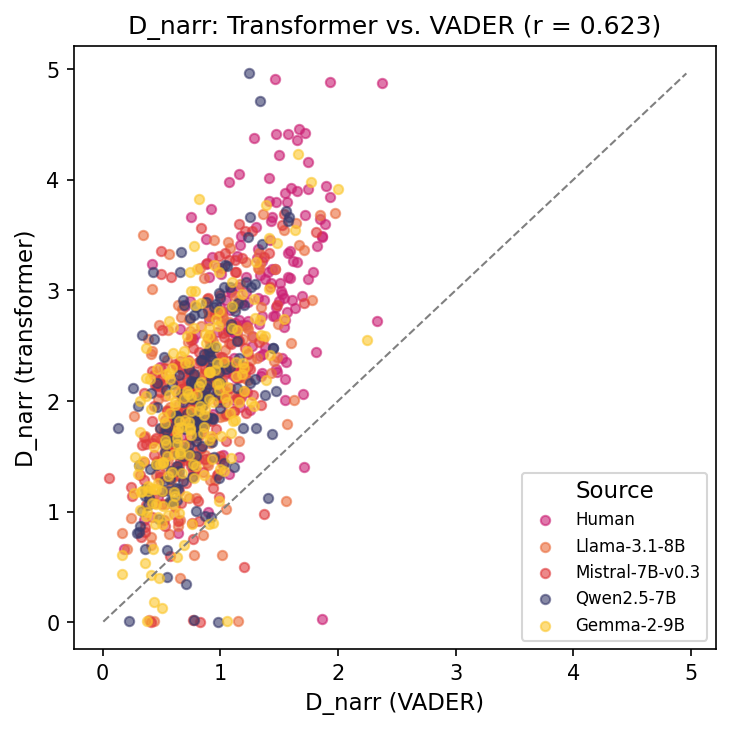

In [88]:
# Visual comparison: D_narr (transformer) vs. D_narr (VADER), per (prompt, source)
fig, ax = plt.subplots(figsize=(5, 5))
for source in present_sources:
    sub = comparison_vader[comparison_vader['source'] == source]
    label = MODEL_LABELS[source]
    ax.scatter(sub['D_narr_vader'], sub['D_narr'], color=MODEL_COLORS[label], alpha=0.6, label=label, s=20)

lims = [comparison_vader[['D_narr', 'D_narr_vader']].min().min(),
        comparison_vader[['D_narr', 'D_narr_vader']].max().max()]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('D_narr (VADER)')
ax.set_ylabel('D_narr (transformer)')
ax.set_title(f'D_narr: Transformer vs. VADER (r = {r_vader:.3f})', fontsize=12)
ax.legend(title='Source', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'd_narr_transformer_vs_vader.png', dpi=300, bbox_inches='tight')
plt.show()